# Neural Network Hyperparameter Tuning — Parkinson's Speech Features

Uses **Optuna** (Bayesian TPE optimisation) with **5-fold grouped cross-validation** to find the best:
- Number of hidden layers (1–4)
- Units per layer
- Activation function (relu, selu, elu, tanh)
- Dropout rate
- L2 regularisation strength
- Learning rate
- Batch size
- Batch normalisation on/off

Metric optimised: **mean CV ROC-AUC** (same as `neural_net_keras.ipynb`).

## 1. Imports & reproducibility

In [2]:
import os, random, warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import optuna
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42

def set_seeds(seed=SEED):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seeds()
print('TF version:', tf.__version__)
print('Optuna version:', optuna.__version__)

/Users/inesvallot/Library/Python/3.10/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TF version: 2.21.0
Optuna version: 4.8.0


## 2. Load & preprocess data

In [3]:
df = pd.read_csv('pd_speech_features.csv', skiprows=1)
print('Dataset shape:', df.shape)

X = df.drop(columns=['class', 'id'])
y = df['class']
groups = df['id']

# Grouped 80/20 train-test split (no patient leakage)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train_raw = X.iloc[train_idx].copy()
X_test_raw  = X.iloc[test_idx].copy()
y_train     = y.iloc[train_idx].copy()
y_test      = y.iloc[test_idx].copy()
train_groups = groups.iloc[train_idx].copy()

# Remove highly correlated features (fit on train only)
corr = X_train_raw.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.96)]
X_train_raw = X_train_raw.drop(columns=to_drop)
X_test_raw  = X_test_raw.drop(columns=to_drop)
print(f'Features after correlation filter: {X_train_raw.shape[1]}')

# Feature selection: mutual information, k=100 (fast default; tune separately if desired)
N_FEATURES = 100
selector = SelectKBest(mutual_info_classif, k=N_FEATURES)
selector.fit(X_train_raw, y_train)
selected_cols = X_train_raw.columns[selector.get_support()]

X_train_sel = pd.DataFrame(selector.transform(X_train_raw), columns=selected_cols, index=X_train_raw.index)
X_test_sel  = pd.DataFrame(selector.transform(X_test_raw),  columns=selected_cols, index=X_test_raw.index)
print(f'Features after MI selection: {X_train_sel.shape[1]}')

# Class weights (imbalanced dataset)
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print(f'Class weights: {class_weight_dict}')

Dataset shape: (756, 755)
Features after correlation filter: 539
Features after MI selection: 100
Class weights: {np.int64(0): np.float64(2.01), np.int64(1): np.float64(0.6655629139072847)}


## 3. Model builder

In [4]:
def build_model(trial, input_dim):
    """Build a Keras model from an Optuna trial's hyperparameters."""
    tf.keras.backend.clear_session()

    n_layers     = trial.suggest_int('n_layers', 1, 4)
    activation   = trial.suggest_categorical('activation', ['relu', 'selu', 'elu', 'tanh'])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.6, step=0.05)
    l2_strength  = trial.suggest_float('l2_strength', 1e-4, 1e-1, log=True)
    lr           = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    use_bn       = trial.suggest_categorical('use_batch_norm', [True, False])

    reg = tf.keras.regularizers.l2(l2_strength)
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))

    for i in range(n_layers):
        units = trial.suggest_categorical(f'units_l{i}', [16, 32, 64, 128, 256])
        model.add(tf.keras.layers.Dense(units, kernel_regularizer=reg))
        if use_bn:
            model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Activation(activation))
        if dropout_rate > 0:
            model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model

## 4. Optuna objective — 5-fold grouped CV

In [6]:
group_kfold = GroupKFold(n_splits=5)
X_arr = X_train_sel.values
y_arr = y_train.values
g_arr = train_groups.values

def objective(trial):
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    fold_aucs  = []

    for fold, (tr_idx, val_idx) in enumerate(
        group_kfold.split(X_arr, y_arr, g_arr), start=1
    ):
        X_tr, X_val = X_arr[tr_idx], X_arr[val_idx]
        y_tr, y_val = y_arr[tr_idx], y_arr[val_idx]

        scaler = StandardScaler()
        X_tr  = scaler.fit_transform(X_tr)
        X_val = scaler.transform(X_val)

        set_seeds(SEED + fold)
        model = build_model(trial, input_dim=X_tr.shape[1])

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_auc', mode='max', patience=15, restore_best_weights=True
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6
            ),
        ]

        model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=200,
            batch_size=batch_size,
            class_weight=class_weight_dict,
            callbacks=callbacks,
            verbose=0
        )

        proba = model.predict(X_val, verbose=0).ravel()
        fold_aucs.append(roc_auc_score(y_val, proba))

        # Prune unpromising trials early (after fold 2)
        if fold >= 2:
            trial.report(np.mean(fold_aucs), fold)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    return float(np.mean(fold_aucs))

## 5. Run the search

Set `N_TRIALS` to control the budget. 50 trials ~20–40 min on CPU; 100 for a thorough search.

In [7]:
N_TRIALS = 50  # increase for more thorough search

sampler = optuna.samplers.TPESampler(seed=SEED)
pruner  = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=1)

study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    pruner=pruner,
    study_name='parkinsons_nn_tuning'
)

print(f'Running {N_TRIALS} Optuna trials (TPE + MedianPruner) …')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nBest CV ROC-AUC : {study.best_value:.4f}')
print('Best hyperparams:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Running 50 Optuna trials (TPE + MedianPruner) …


Best trial: 36. Best value: 0.895945: 100%|██████████| 50/50 [08:32<00:00, 10.26s/it]


Best CV ROC-AUC : 0.8959
Best hyperparams:
  batch_size: 16
  n_layers: 4
  activation: relu
  dropout_rate: 0.30000000000000004
  l2_strength: 0.03431555513740929
  learning_rate: 0.0034412139079499685
  use_batch_norm: True
  units_l0: 256
  units_l1: 64
  units_l2: 256
  units_l3: 32


## 6. Results table

In [8]:
trials_df = study.trials_dataframe(attrs=('number', 'value', 'params', 'state'))
completed = trials_df[trials_df['state'] == 'COMPLETE'].copy()
completed = completed.sort_values('value', ascending=False).reset_index(drop=True)

print('Top 10 completed trials:')
display(completed.head(10))

Top 10 completed trials:


,number,value,params_activation,params_batch_size,params_dropout_rate,params_l2_strength,params_learning_rate,params_n_layers,params_units_l0,params_units_l1,params_units_l2,params_units_l3,params_use_batch_norm,state
0,36,0.895945,relu,16,0.30,0.034316,0.003441,4,256,64.0,256.0,32.0,True,COMPLETE
1,45,0.894195,relu,16,0.35,0.034069,0.002475,4,32,64.0,64.0,32.0,True,COMPLETE
2,47,0.892351,relu,16,0.35,0.032993,0.003023,2,32,64.0,NaN,NaN,True,COMPLETE
3,48,0.888118,relu,16,0.30,0.021062,0.001170,2,32,64.0,NaN,NaN,True,COMPLETE
4,46,0.886681,relu,16,0.35,0.021944,0.002554,3,32,64.0,64.0,NaN,True,COMPLETE
5,34,0.885435,relu,16,0.40,0.044283,0.006482,3,256,64.0,16.0,NaN,True,COMPLETE
6,43,0.882623,relu,16,0.35,0.065531,0.005349,4,32,64.0,64.0,32.0,True,COMPLETE
7,44,0.882494,relu,16,0.35,0.066699,0.002467,4,32,64.0,64.0,32.0,True,COMPLETE
8,8,0.881422,relu,64,0.15,0.049621,0.001633,4,256,64.0,64.0,256.0,False,COMPLETE
9,49,0.880914,elu,16,0.30,0.021451,0.001092,2,32,64.0,NaN,NaN,True,COMPLETE


## 7. Visualise the search

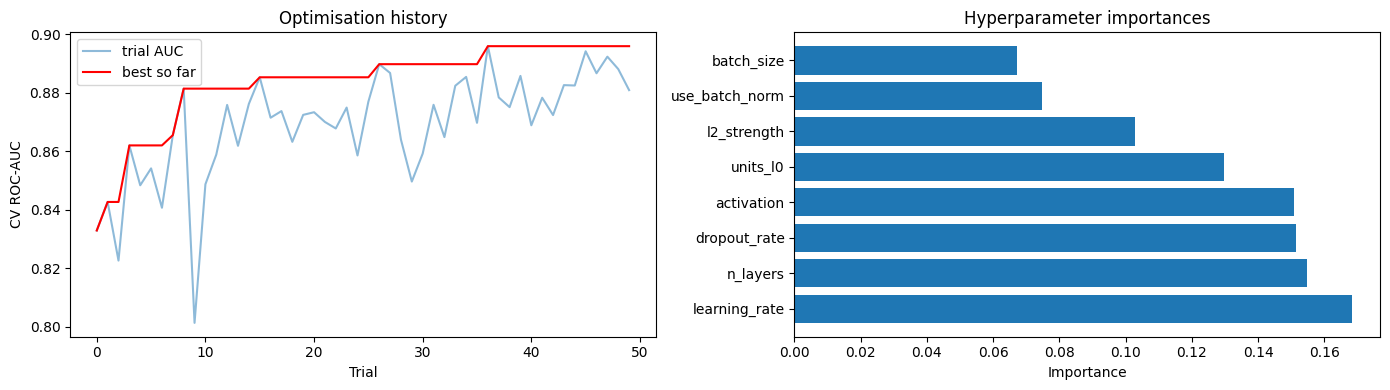

In [9]:
# Optimisation history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vals   = [t.value for t in study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(vals)

axes[0].plot(vals, alpha=0.5, label='trial AUC')
axes[0].plot(best_so_far, color='red', label='best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('CV ROC-AUC')
axes[0].set_title('Optimisation history')
axes[0].legend()

# Hyperparameter importance
try:
    importances = optuna.importance.get_param_importances(study)
    names, scores = zip(*importances.items())
    axes[1].barh(names, scores)
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Hyperparameter importances')
except Exception:
    axes[1].set_title('Importance not available (need more trials)')

plt.tight_layout()
plt.show()

## 8. Retrain best model on full training set

In [10]:
best_params = study.best_params.copy()
print('Retraining with best params:', best_params)

scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_sel)
X_test_scaled  = scaler_final.transform(X_test_sel)

set_seeds(SEED)
tf.keras.backend.clear_session()

# Rebuild model manually from best_params
n_layers     = best_params['n_layers']
activation   = best_params['activation']
dropout_rate = best_params['dropout_rate']
l2_strength  = best_params['l2_strength']
lr           = best_params['learning_rate']
use_bn       = best_params['use_batch_norm']
batch_size   = best_params['batch_size']

reg = tf.keras.regularizers.l2(l2_strength)
best_model = tf.keras.Sequential()
best_model.add(tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)))

for i in range(n_layers):
    units = best_params[f'units_l{i}']
    best_model.add(tf.keras.layers.Dense(units, kernel_regularizer=reg))
    if use_bn:
        best_model.add(tf.keras.layers.BatchNormalization())
    best_model.add(tf.keras.layers.Activation(activation))
    if dropout_rate > 0:
        best_model.add(tf.keras.layers.Dropout(dropout_rate))

best_model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)
best_model.summary()

callbacks_final = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', mode='max', patience=20, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6
    ),
]

history = best_model.fit(
    X_train_scaled, y_train,
    validation_split=0.15,
    epochs=300,
    batch_size=batch_size,
    class_weight=class_weight_dict,
    callbacks=callbacks_final,
    verbose=1
)

Retraining with best params: {'batch_size': 16, 'n_layers': 4, 'activation': 'relu', 'dropout_rate': 0.30000000000000004, 'l2_strength': 0.03431555513740929, 'learning_rate': 0.0034412139079499685, 'use_batch_norm': True, 'units_l0': 256, 'units_l1': 64, 'units_l2': 256, 'units_l3': 32}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,633 (272.00 KB)

 Trainable params: 68,417 (267.25 KB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6562 - auc: 0.6911 - loss: 9.7111 - val_accuracy: 0.6264 - val_auc: 0.8172 - val_loss: 6.3466 - learning_rate: 0.0034
Epoch 2/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7461 - auc: 0.8199 - loss: 4.4287 - val_accuracy: 0.7363 - val_auc: 0.8191 - val_loss: 3.0647 - learning_rate: 0.0034
Epoch 3/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7969 - auc: 0.8345 - loss: 2.1952 - val_accuracy: 0.7582 - val_auc: 0.8161 - val_loss: 1.8052 - learning_rate: 0.0034
Epoch 4/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8027 - auc: 0.8535 - loss: 1.4214 - val_accuracy: 0.7473 - val_auc: 0.8355 - val_loss: 1.4032 - learning_rate: 0.0034
Epoch 5/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8340 - auc: 0.8810 - loss: 1.1499 - val_accuracy: 0.7473 - val_auc: 0.7944 - val_loss: 1.3202 - learning_rate: 0.0034
Epoch 6/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7559 - auc: 0.8535 -

## 9. Test-set evaluation

In [11]:
test_proba = best_model.predict(X_test_scaled, verbose=0).ravel()
test_pred  = (test_proba >= 0.5).astype(int)

print('=== Test set results (threshold = 0.5) ===')
print(classification_report(y_test, test_pred))
print('Confusion matrix:')
print(confusion_matrix(y_test, test_pred))
print(f'Test ROC-AUC: {roc_auc_score(y_test, test_proba):.4f}')

print('\n--- Threshold sweep ---')
for t in np.arange(0.30, 0.71, 0.05):
    pred_t = (test_proba >= t).astype(int)
    from sklearn.metrics import f1_score
    f1 = f1_score(y_test, pred_t, zero_division=0)
    auc = roc_auc_score(y_test, test_proba)
    print(f'  t={t:.2f}  F1={f1:.3f}  AUC={auc:.4f}')

=== Test set results (threshold = 0.5) ===
              precision    recall  f1-score   support

           0       0.54      0.83      0.65        42
           1       0.92      0.73      0.81       111

    accuracy                           0.76       153
   macro avg       0.73      0.78      0.73       153
weighted avg       0.82      0.76      0.77       153

Confusion matrix:
[[35  7]
 [30 81]]
Test ROC-AUC: 0.8788

--- Threshold sweep ---
  t=0.30  F1=0.904  AUC=0.8788
  t=0.35  F1=0.894  AUC=0.8788
  t=0.40  F1=0.884  AUC=0.8788
  t=0.45  F1=0.867  AUC=0.8788
  t=0.50  F1=0.814  AUC=0.8788
  t=0.55  F1=0.784  AUC=0.8788
  t=0.60  F1=0.745  AUC=0.8788
  t=0.65  F1=0.717  AUC=0.8788
  t=0.70  F1=0.714  AUC=0.8788


## 10. Training history of final model

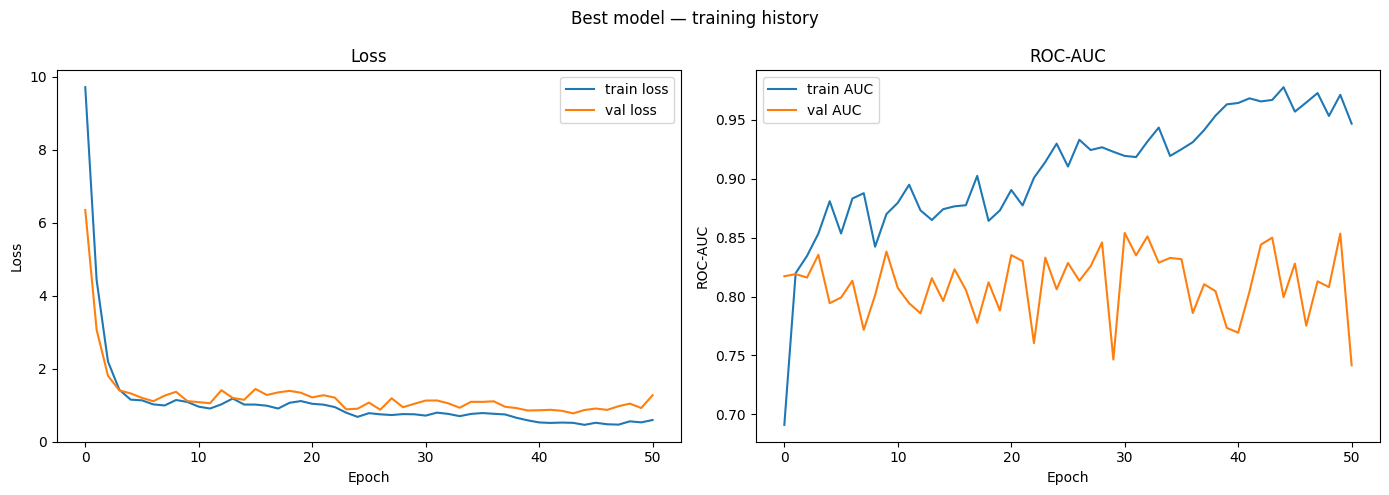

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='train loss')
axes[0].plot(history.history['val_loss'], label='val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history.history['auc'],     label='train AUC')
axes[1].plot(history.history['val_auc'], label='val AUC')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC'); axes[1].legend()

plt.suptitle('Best model — training history')
plt.tight_layout()
plt.show()

## 11. Summary

In [13]:
print('=== TUNING SUMMARY ===')
print(f'Trials run        : {len(study.trials)}')
print(f'Best CV ROC-AUC   : {study.best_value:.4f}')
print(f'Test ROC-AUC      : {roc_auc_score(y_test, test_proba):.4f}')
print()
print('Best architecture:')
print(f'  Hidden layers   : {n_layers}')
layer_shapes = [best_params[f"units_l{i}"] for i in range(n_layers)]
print(f'  Layer sizes     : {layer_shapes}')
print(f'  Activation      : {activation}')
print(f'  Dropout         : {dropout_rate}')
print(f'  L2 strength     : {l2_strength:.2e}')
print(f'  Learning rate   : {lr:.2e}')
print(f'  Batch size      : {batch_size}')
print(f'  Batch norm      : {use_bn}')

=== TUNING SUMMARY ===
Trials run        : 50
Best CV ROC-AUC   : 0.8959
Test ROC-AUC      : 0.8788

Best architecture:
  Hidden layers   : 4
  Layer sizes     : [256, 64, 256, 32]
  Activation      : relu
  Dropout         : 0.30000000000000004
  L2 strength     : 3.43e-02
  Learning rate   : 3.44e-03
  Batch size      : 16
  Batch norm      : True
